# 01 - Exploratory Data Analysis

Dataset: Kaggle "Brain Tumor MRI Dataset" v2 (4 classes: glioma, meningioma, pituitary, notumor).

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash
from tqdm.auto import tqdm

c:\Users\briek\Desktop\AI_Portfolio\brain-tumor-mri-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Paths

In [ ]:
DATA_DIR = Path("..") / "data"
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

## 3. Class distribution

### 3.1 Image table

One row per image. Split and label come from the folder names: `data/<split>/<label>/<file>.jpg`.

In [3]:
paths = sorted(DATA_DIR.glob("*/*/*.jpg"))

df = pd.DataFrame({"path": paths})
df["split"] = [p.parent.parent.name for p in paths]
df["label"] = [p.parent.name for p in paths]
df.head()

,path,split,label
0,..\data\Testing\glioma\Te-gl_1.jpg,Testing,glioma
1,..\data\Testing\glioma\Te-gl_10.jpg,Testing,glioma
2,..\data\Testing\glioma\Te-gl_100.jpg,Testing,glioma
3,..\data\Testing\glioma\Te-gl_101.jpg,Testing,glioma
4,..\data\Testing\glioma\Te-gl_102.jpg,Testing,glioma


### 3.2 Counts per class and split

In [ ]:
counts = pd.crosstab(df["label"], df["split"], margins=True, margins_name="total")
counts

split,Testing,Training,total
label,,,
glioma,400,1400,1800
meningioma,400,1400,1800
notumor,400,1400,1800
pituitary,400,1400,1800
total,1600,5600,7200


### 3.3 Plot

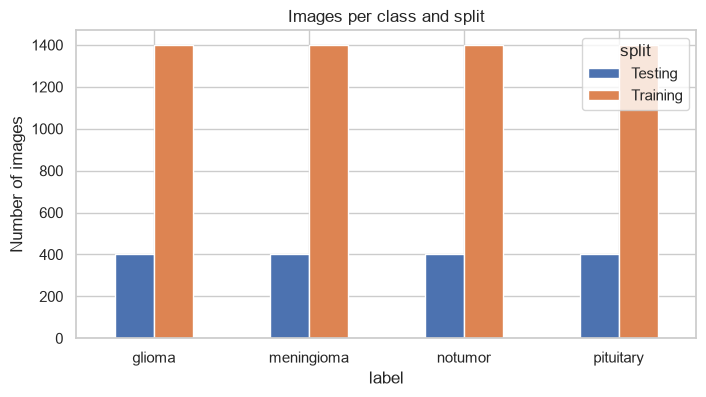

In [5]:
counts.drop(index="total", columns="total").plot(kind="bar", rot=0, figsize=(8, 4), title="Images per class and split")
plt.ylabel("Number of images")
plt.show()

### 3.4 Conclusions

- 7,200 images: 1,400 train and 400 test per class, so the classes are perfectly balanced.
- This balance is partly artificial: many notumor images are duplicates (see section 6).
- No validation set yet: it will be split off from the training data in `02_preprocessing`.

## 4. Image size and color mode

### 4.1 Read size and mode


In [6]:
df["width"] = [Image.open(p).width for p in paths]
df["height"] = [Image.open(p).height for p in paths]
df["mode"] = [Image.open(p).mode for p in paths]
df["size"] = df["width"].astype(str) + "x" + df["height"].astype(str)
df.head()

,path,split,label,width,height,mode,size
0,..\data\Testing\glioma\Te-gl_1.jpg,Testing,glioma,354,442,RGB,354x442
1,..\data\Testing\glioma\Te-gl_10.jpg,Testing,glioma,512,512,L,512x512
2,..\data\Testing\glioma\Te-gl_100.jpg,Testing,glioma,512,512,L,512x512
3,..\data\Testing\glioma\Te-gl_101.jpg,Testing,glioma,512,512,L,512x512
4,..\data\Testing\glioma\Te-gl_102.jpg,Testing,glioma,339,406,RGB,339x406


### 4.2 Color mode per class

`L` = grayscale, `RGB` = color, `P` = palette, `RGBA` = color with transparency.

In [16]:
pd.crosstab(df["label"], df["mode"])

mode,L,P,RGB,RGBA
label,,,,
glioma,1399,0,401,0
meningioma,709,0,1091,0
notumor,29,1,1767,3
pituitary,930,0,870,0


### 4.3 Size per class

In [17]:
df["square"] = df["width"] == df["height"]

df.groupby("label").agg(
    median_width=("width", "median"),
    median_height=("height", "median"),
    n_sizes=("size", "nunique"),
    square_share=("square", "mean"),
)

,median_width,median_height,n_sizes,square_share
label,,,,
glioma,512.0,512.0,62,0.963889
meningioma,512.0,512.0,126,0.882222
notumor,228.0,243.0,250,0.321667
pituitary,512.0,512.0,27,0.980556


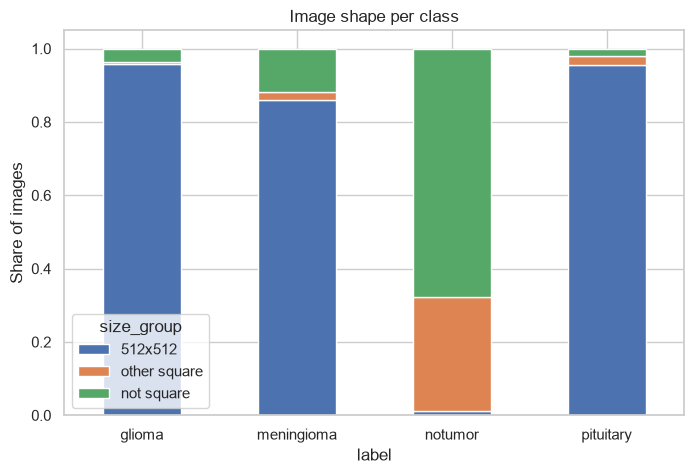

In [18]:
df["size_group"] = np.where(df["size"] == "512x512", "512x512", np.where(df["square"], "other square", "not square"))

size_groups = pd.crosstab(df["label"], df["size_group"], normalize="index")[["512x512", "other square", "not square"]]
size_groups.plot(kind="bar", stacked=True, rot=0, figsize=(8, 5), title="Image shape per class")
plt.ylabel("Share of images")
plt.show()

### 4.4 Conclusions

- A lot of the glioma, meningioma and pituitary images are exactly 512x512, compared to only 1% of the notumor images.
- Notumor is much smaller (median ~230 px), has 250 different sizes and about 2/3 are not square.
- Notumor is almost entirely RGB, the other classes are a mix of grayscale and RGB.
- This is a strong sign of source bias: a model could learn "notumor" from size or format instead of the brain.
- Preprocessing must resize all images to one size and convert them to grayscale.

## 5. Sample images

### 5.1 Random samples per class

Five random images per class.

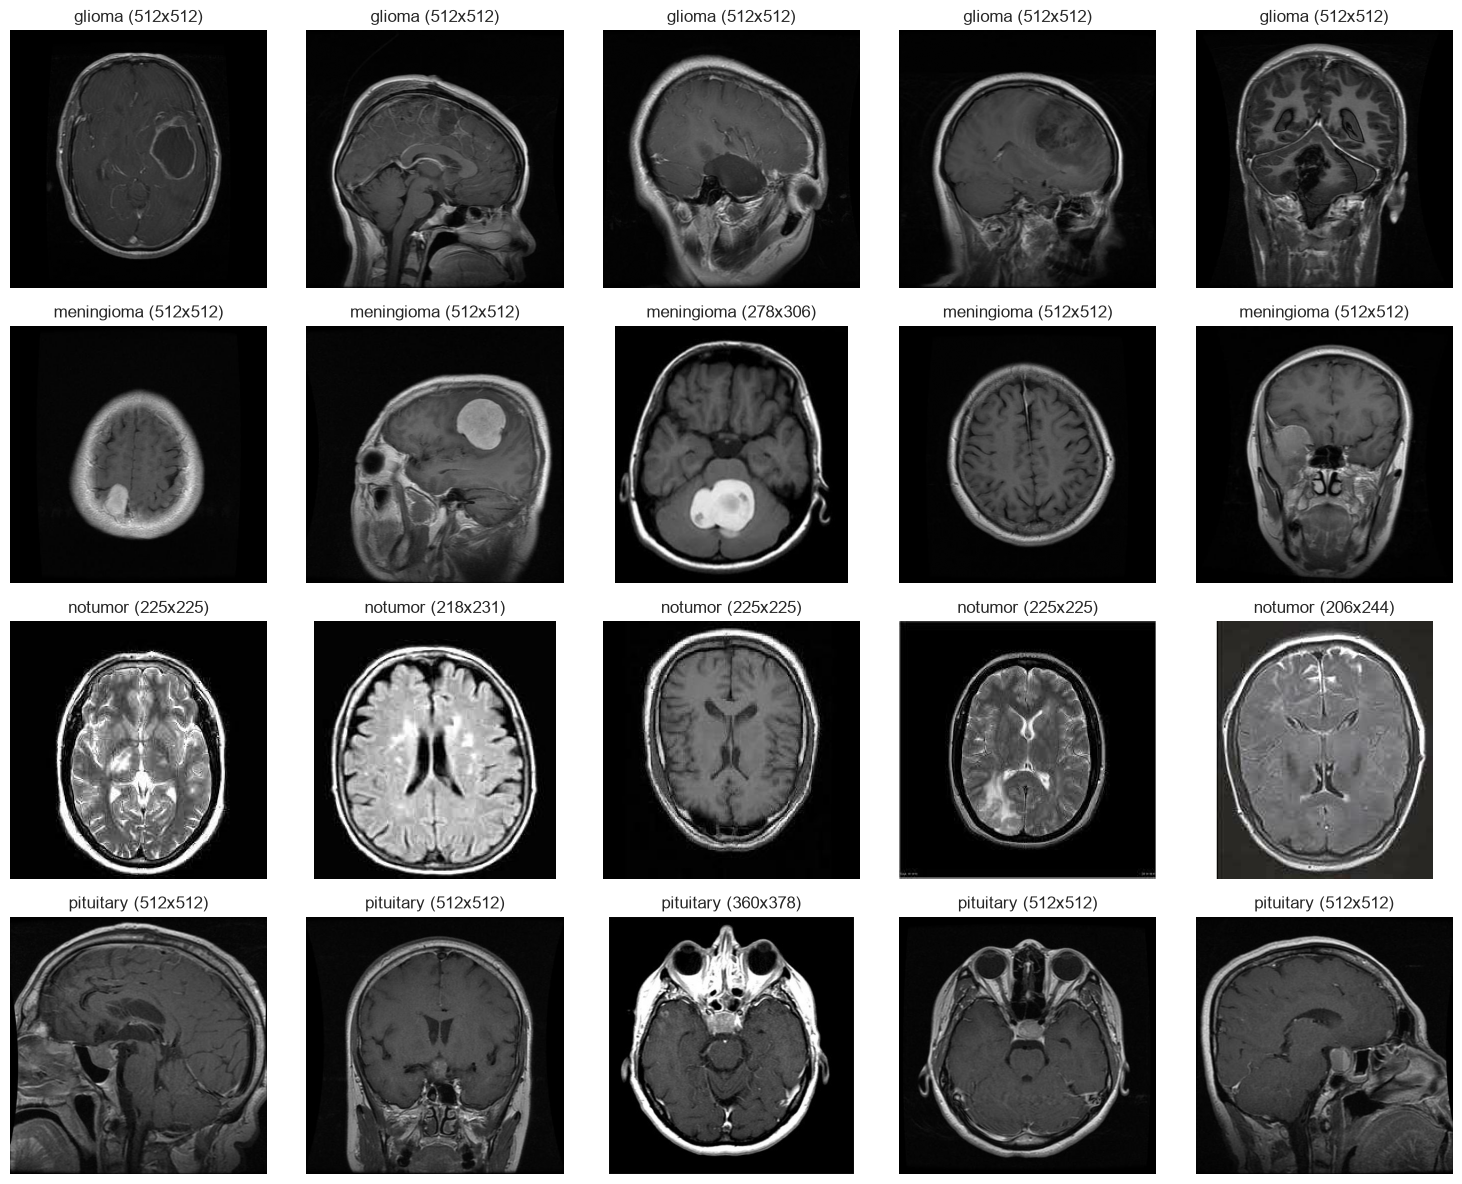

In [19]:
samples = df.groupby("label").sample(n=5, random_state=42)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for ax, path, label, size in zip(axes.flat, samples["path"], samples["label"], samples["size"]):
    ax.imshow(Image.open(path), cmap="gray")
    ax.set_title(f"{label} ({size})")
    ax.axis("off")
plt.tight_layout()
plt.show()

### 5.2 Conclusions

- Glioma: dark, irregular areas. Meningioma: bright, round masses near the skull. Pituitary: small changes at the base of the brain.
- Notumor images look much brighter than the other classes, and in this sample they are all seen from above (the tumor classes mix top, side and front views).
- All images have a black border, but its size differs between images.
- A model could learn brightness or viewing angle instead of the tumor (shortcut learning). Grad-CAM in `04_evaluation` must check this.

## 6. Duplicates and leakage

### 6.1 Perceptual hash

A perceptual hash is a short fingerprint of what an image looks like.
Images that look the same get the same hash, even if they are resized or saved differently.

In [20]:
df["hash"] = [str(imagehash.phash(Image.open(p))) for p in tqdm(paths)]
df[["path", "label", "hash"]].head()

100%|██████████| 7200/7200 [00:12<00:00, 595.88it/s]


,path,label,hash
0,..\data\Testing\glioma\Te-gl_1.jpg,glioma,d45e0b6f6ec43a30
1,..\data\Testing\glioma\Te-gl_10.jpg,glioma,d2383ff069c36147
2,..\data\Testing\glioma\Te-gl_100.jpg,glioma,93376ec86d49318d
3,..\data\Testing\glioma\Te-gl_101.jpg,glioma,c55a2f692ea76834
4,..\data\Testing\glioma\Te-gl_102.jpg,glioma,c53a1a631b253cf5


### 6.2 Duplicate groups

One row per unique hash: how many images share it, and in how many splits and labels they appear.

In [21]:
groups = df.groupby("hash").agg(
    n_images=("path", "size"),
    n_splits=("split", "nunique"),
    n_labels=("label", "nunique"),
)
dup_groups = groups[groups["n_images"] > 1]

len(dup_groups), df["hash"].duplicated().sum()

(592, np.int64(988))

In [22]:
duplicates = df[df["hash"].duplicated(keep=False)]
pd.crosstab(duplicates["label"], duplicates["split"])

split,Testing,Training
label,,
glioma,38,10
meningioma,109,139
notumor,312,886
pituitary,2,84


### 6.3 Leakage between train and test

Test images that also appear in the training set. The model has already seen these during training.

In [23]:
train_hashes = df.loc[df["split"] == "Training", "hash"]
leaked = df[(df["split"] == "Testing") & df["hash"].isin(train_hashes)]

len(leaked), leaked["label"].value_counts()

(370,
 label
 notumor       257
 meningioma    105
 glioma          6
 pituitary       2
 Name: count, dtype: int64)

### 6.4 Label conflicts

The same image with different labels.

In [24]:
conflict_hashes = dup_groups[dup_groups["n_labels"] > 1].index
df.loc[df["hash"].isin(conflict_hashes), ["path", "split", "label", "hash"]]

,path,split,label,hash
365,..\data\Testing\glioma\Te-gl_68.jpg,Testing,glioma,901a7f616de436a6
796,..\data\Testing\meningioma\Te-me_96.jpg,Testing,meningioma,901a7f616de436a6
3799,..\data\Training\meningioma\Tr-me_458.jpg,Training,meningioma,901a7f616de436a6


### 6.5 Example of a duplicate group

The largest group: the same scan, saved many times in both train and test.

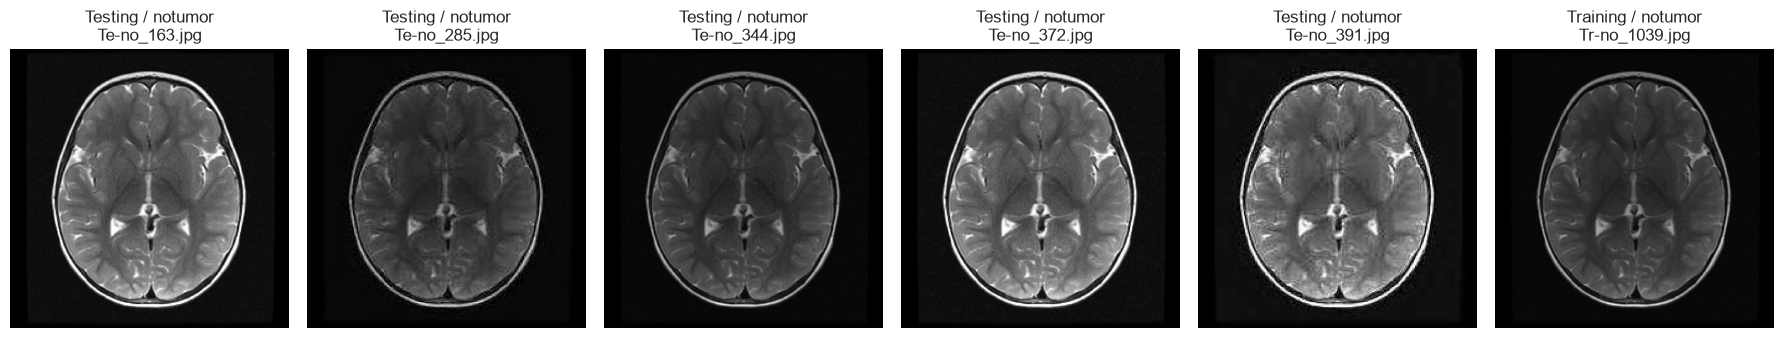

In [25]:
biggest = dup_groups["n_images"].idxmax()
examples = df[df["hash"] == biggest].head(6)

fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
for ax, path, split, label in zip(axes, examples["path"], examples["split"], examples["label"]):
    ax.imshow(Image.open(path), cmap="gray")
    ax.set_title(f"{split} / {label}\n{path.name}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### 6.6 Conclusions

- 592 groups of duplicates: 988 images (14% of the dataset) are copies of another image. Most of them are notumor.
- The duplicates are probably the result of oversampling by the dataset creator to balance the classes.
  That is a valid technique for training data, but here it was done before the train/test split, so copies ended up in the test set.
- Leakage: 370 of the 1,600 test images also appear in the training set. For notumor this is 257 of 400.
  A test score on this split would be too optimistic, especially for notumor.
- One image is labeled both glioma and meningioma: a labeling error.
- Plan for `02_preprocessing`: drop the conflicting image, remove training images that also appear in test,
  and keep one image per duplicate group in both train and test.
- After cleaning, notumor drops to 720 training images (the other classes keep ~1,300). This imbalance is handled with class weights in `03_training`.
- Limitation: only identical hashes are found, and there are no patient IDs, so different scans of the same patient can still end up in both train and test.